In [ ]:
# %cd ..
# import mytangram as tg

In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

C:\Users\enric\tangram\.venv\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\enric\tangram\.venv\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
!uv pip install winshell

Using Python 3.10.17 environment at: C:\Users\enric\tangram\.venv
Audited 1 package in 30ms


In [3]:
import winshell
import os

shortcut_path = r"H:/Il mio Drive/dati_per_enrico.lnk"
real_path = winshell.shortcut(shortcut_path).path

print(f"Real path: {real_path}")

# Now test it
if os.path.exists(real_path):
    print("Resolved path is accessible")
else:
    print("Resolved path is not available")

Real path: H:\.shortcut-targets-by-id\1UGLL2UOn-9s1OY1r9mGMc1RFF7REij9e\dati_per_enrico
Resolved path is accessible


In [4]:
%cd H:/Il mio Drive/

H:\Il mio Drive


C:\Users\enric\tangram\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [ ]:
!dir

## Load data

In [16]:
## Load full  scRNA datasets
adata_sc= sc.read_h5ad('H:/Il mio Drive/dati_per_enrico.lnk/counts100k_norm_wo_raw.h5ad')
print(adata_sc)
print("adata.X dtype: " + np.dtype(adata_sc.X))  # float64
# Down-cast to float32 to make lighter
adata_sc.X = adata_sc.X.astype("float32").tocsr()
adata_sc.write(filename='H:/Il mio Drive/data_tangram/counts100k_norm_wo_raw_light.h5ad')

AnnData object with n_obs × n_vars = 100000 × 31053
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC'
    var: 'gene_ids', 'feature_types'
float64


In [ ]:
# Load lightweight scRNA dataset
adata_sc = ad.read_h5ad("H:/Il mio Drive/data_tangram/counts100k_norm_wo_raw_light.h5ad")
adata_sc

In [6]:
# Load spatial dataset (smallest)
adata_st = ad.read_h5ad("H:/Il mio Drive/dati_per_enrico.lnk/slice200_norm_wo_raw.h5ad")
adata_st

AnnData object with n_obs × n_vars = 2155 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial'
    uns: 'spatialdata_attrs'

# Cell lables exploration
We first explore the different levels of clustering/labelling available for the the cells of our dataset.

## scRNA Data
The sc dataset has multiple Allen Brain Atlas cell annotations:

In [30]:
labels = ['cluster', 'Allen.cluster_label', 'Allen.class_label', 'Allen.subclass_label']
for label in labels:
    # print(f"Number of {label} values: {adata_sc.obs[label].nunique()}")
    print(f"{label} unique values: {adata_sc.obs[label].unique()} \n")

cluster unique values: ['Ex3_5', 'Fibro1_5', 'Oligo_21', 'Micro_0', 'Ex5_2', ..., 'Int1_20', 'Macrophage_5', 'Fibro2_4', 'DMS_5', 'Fibro1_9']
Length: 222
Categories (222, object): ['Astro_0', 'Astro_1', 'Astro_2', 'Astro_3', ..., 'Stalk_10', 'Stalk_11', 'Stalk_12', 'Stalk_13'] 

Allen.cluster_label unique values: ['L6 CT Cpa6', 'VLMC_3', 'Oligo Opalin_4', 'Macrophage_2', 'L5/6 NP_3', ..., 'L2/3 IT_1_1', 'Pvalb Gpr149_2', 'VLMC/Endo', 'Pvalb Nkx2.1', 'Pvalb Il1rapl2_2_5']
Length: 154
Categories (153, object): ['Astro Aqp4_1', 'Astro Aqp4_2', 'Astro Aqp4_3', 'Astro Aqp4_4', ..., 'Vip Igfbp6_1', 'Vip Igfbp6_2', 'Vip Serpinf1_1', 'Vip Serpinf1_2'] 

Allen.class_label unique values: ['Glutamatergic', 'Non-Neuronal', NaN, 'GABAergic', 'Low Quality']
Categories (4, object): ['GABAergic', 'Glutamatergic', 'Low Quality', 'Non-Neuronal'] 

Allen.subclass_label unique values: ['L6 CT', 'VLMC', 'Oligo', 'Macrophage', 'L5/6 NP', ..., 'Vip', 'Prog/IP', 'Peri', 'CR', 'SMC']
Length: 27
Categories (26,

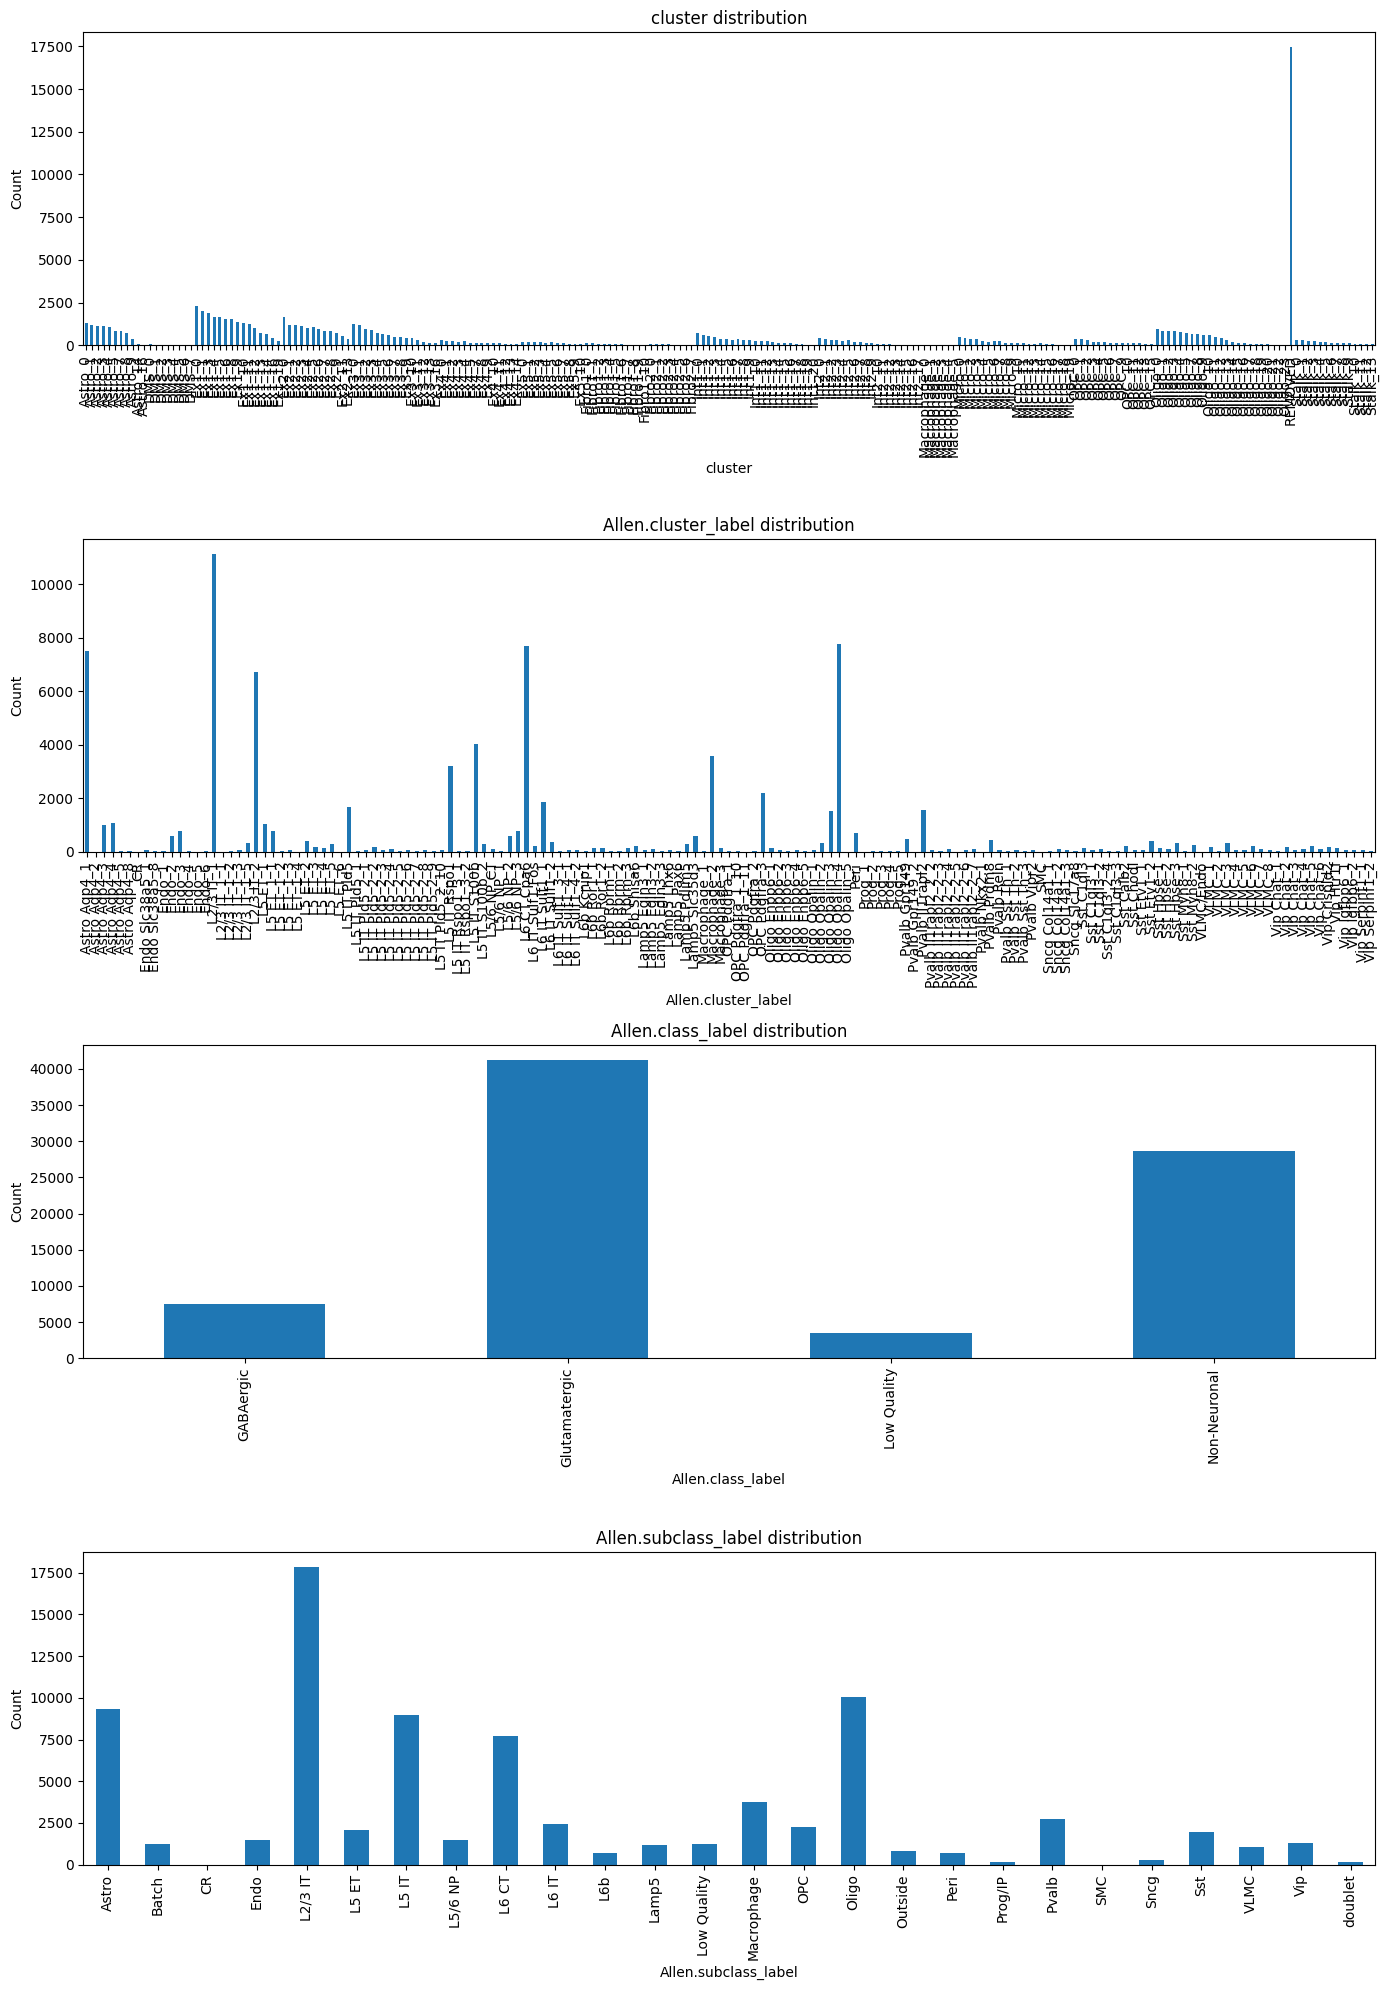

In [32]:
fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=False)

for ax, label in zip(axes, labels):
    adata_sc.obs[label].value_counts().sort_index().plot(
        kind='bar', ax=ax, rot=90
    )
    ax.set_title(f"{label} distribution")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

## Spatial Data
Similary does the spatial dataset:

In [33]:
labels = ['class_label', 'subclass', 'label']
for label in labels:
    # print(f"Number of {label} values: {adata_st.obs[label].nunique()}")
    print(f"{label} unique values: {adata_st.obs[label].unique()} \n")

class_label unique values: ['Other', 'Glutamatergic', 'GABAergic']
Categories (3, object): ['GABAergic', 'Glutamatergic', 'Other'] 

subclass unique values: ['Endo', 'L4/5 IT', 'VLMC', 'L2/3 IT', 'Astro', ..., 'Oligo', 'Sncg', 'OPC', 'Lamp5', 'SMC']
Length: 22
Categories (22, object): ['Astro', 'Endo', 'L2/3 IT', 'L4/5 IT', ..., 'Sncg', 'Sst', 'VLMC', 'Vip'] 

label unique values: ['Endo', 'L45_IT_2', 'VLMC', 'L23_IT_1', 'Astro_2', ..., 'Pvalb_9', 'Sst_1', 'Vip_1', 'Sst_Chodl', 'L6_CT_5']
Length: 81
Categories (81, object): ['Astro_1', 'Astro_2', 'Endo', 'L5_ET_1', ..., 'Vip_5', 'Vip_8', 'Vip_9', 'Vip_10'] 



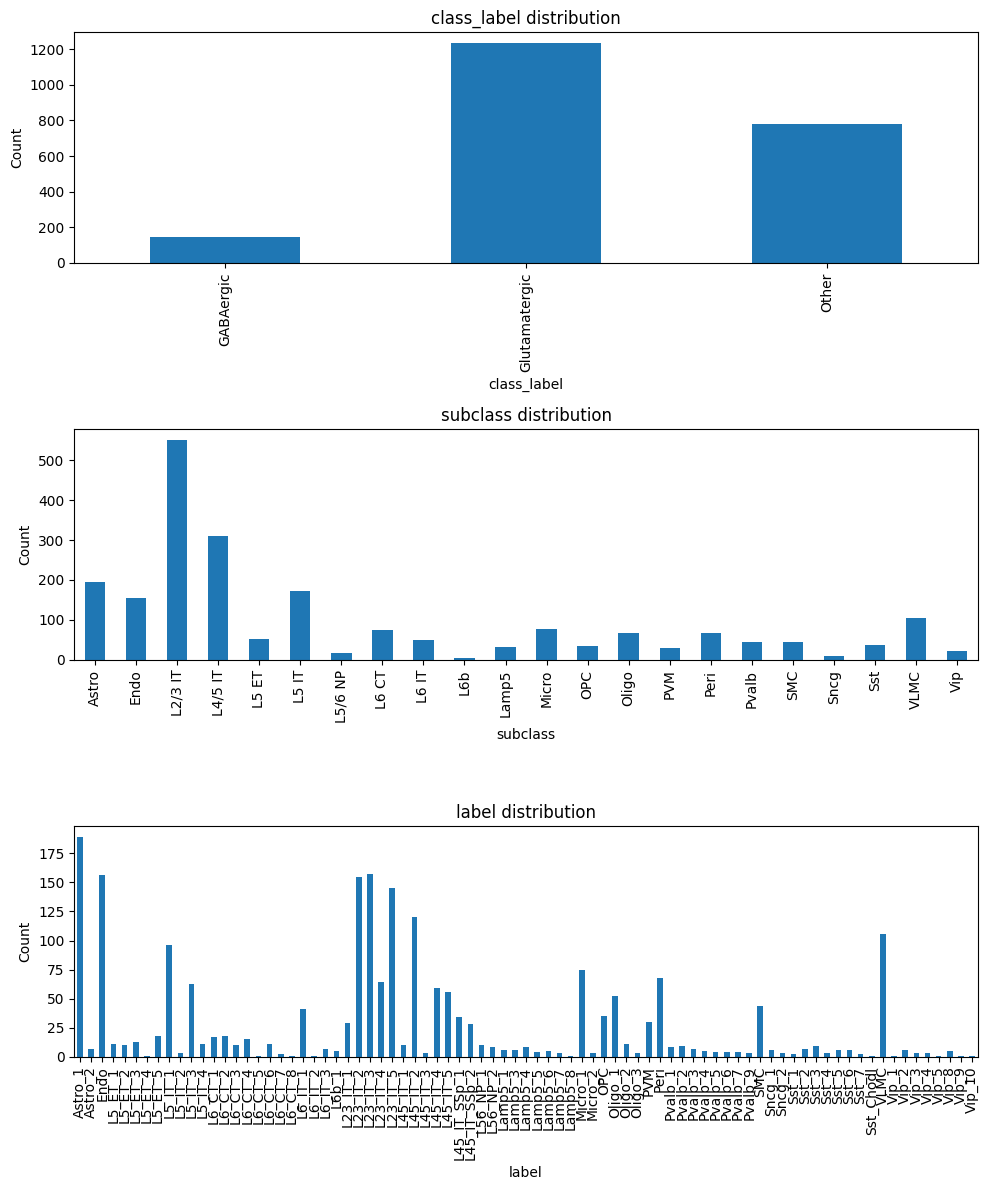

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=False)

for ax, label in zip(axes, labels):
    adata_st.obs[label].value_counts().sort_index().plot(
        kind='bar', ax=ax, rot=90
    )
    ax.set_title(f"{label} distribution")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

We can appreciate that, for both modalities, the most biologically informative labellings are the Allen cell class and subclass annotations, which, in addition, adopt a consistent nomenclature (same classes) making it possible to directly compare the two datasets (for harmonization).

## scRNA Cells pre-processing
Now we can zoom-in the most relevant labels and we notice that the scRNA data contains cells labelled as uninformative:

<Axes: xlabel='Allen.subclass_label'>

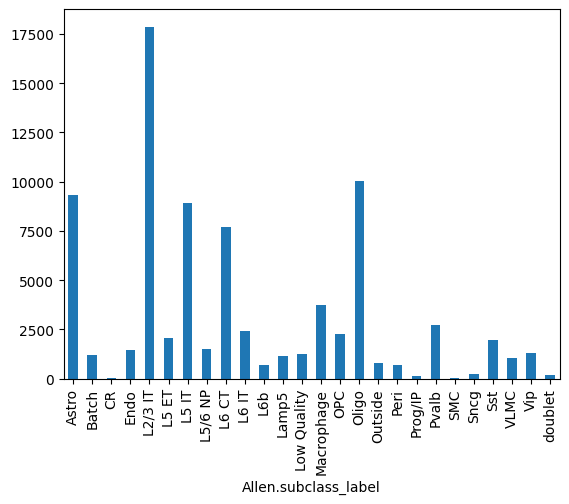

In [7]:
adata_sc.obs['Allen.subclass_label'].value_counts().sort_index().plot(kind='bar')

In [34]:
print('Number of low quality cells: ', len(adata_sc.obs.loc[adata_sc.obs['Allen.subclass_label']=='Low Quality']))
print('Number of doublet cells: ', len(adata_sc.obs.loc[adata_sc.obs['Allen.subclass_label']=='doublet']))
print('Number of outside cells: ', len(adata_sc.obs.loc[adata_sc.obs['Allen.subclass_label']=='Outside']))

Number of low quality cells:  1240
Number of doublet cells:  175
Number of outside cells:  819


That we can also encounter in:

In [40]:
print('Number of low quality cells (class label): ', len(adata_sc.obs.loc[adata_sc.obs['Allen.class_label']=='Low Quality']))
sum_subclass = len(adata_sc.obs.loc[adata_sc.obs['Allen.subclass_label']=='Low Quality']) +\
len(adata_sc.obs.loc[adata_sc.obs['Allen.subclass_label']=='doublet']) +\
len(adata_sc.obs.loc[adata_sc.obs['Allen.subclass_label']=='Outside'])
print(f'Differt from total in subclass label: {sum_subclass}')

Number of low quality cells (class label):  3462
Differt from total in subclass label: 2234


So we check what subclasses low quality class labelled cells correspond to:

<Axes: xlabel='Allen.subclass_label'>

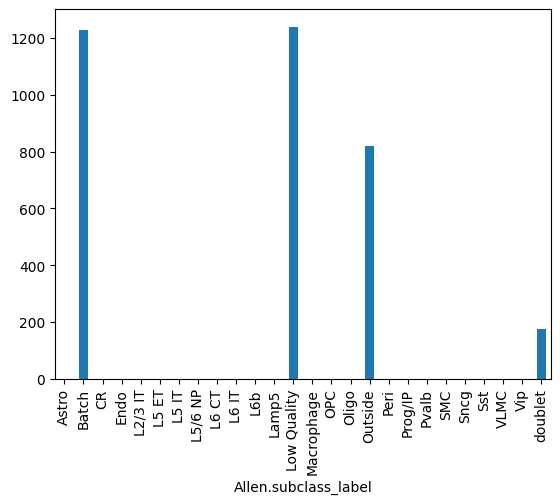

In [43]:
adata_sc.obs['Allen.subclass_label'].loc[adata_sc.obs['Allen.class_label']=='Low Quality'].value_counts().sort_index().plot(kind='bar')

clearly showing that the previous filtering was missing batch effect labelled cells:

In [47]:
print('Number of batch cells: ', len(adata_sc.obs.loc[adata_sc.obs['Allen.subclass_label']=='Batch']))
print(f'check: {3462-2234}')

Number of batch cells:  1228
check: 1228


From this analysis we conclude that we can safely reduce the cardinality of sc observations by dropping uninformative/low quality cells:

In [49]:
# Drop cells above
# adata_sc = adata_sc[~adata_sc.obs['Allen.subclass_label'].isin(['Low Quality', 'doublet', 'Outside', 'Batch'])].copy()
adata_sc = adata_sc[~ (adata_sc.obs['Allen.class_label'] == 'Low Quality')]
adata_sc

View of AnnData object with n_obs × n_vars = 96538 × 31053
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC'
    var: 'gene_ids', 'feature_types'

We must, finally, note that spatial data does not contain any type of labelled low quality samples, even though further pre-processing (with scanpy) could help reducing the size.

#### Missing labels
Before any downstream processing, we need to handle NaN values from the class label column for two main reasons:
1. In the training genes selection, the Spapros selector would place NaN values into a spurious label, breaking the whole procedure.
2. To perform proper harmonization later (spatial data has no missing values, see below).

In [7]:
# Count NA values
print(adata_sc.obs["Allen.class_label"].isna().sum())
print(adata_st.obs["class_label"].isna().sum())  # 0

19201
0


To avoid including uninformative confounding cells, we remove observations with a missing label:

In [8]:
# Remove NAs
adata_sc = adata_sc[adata_sc.obs["Allen.class_label"].notna()].copy()
adata_sc

AnnData object with n_obs × n_vars = 77337 × 31053
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC'
    var: 'gene_ids', 'feature_types'

#### Save-Load filtered sc data
Cell filtered float32 sc data is stored to be used in the genes analysis as a lightweight alternative to the original dataset:

In [9]:
# Write file
adata_sc.write(filename='H:/Il mio Drive/data_tangram/counts100k_light_filt.h5ad')

In [5]:
# Load filtered scRNA dataset
adata_sc = ad.read_h5ad('H:/Il mio Drive/data_tangram/counts100k_light_filt.h5ad')
adata_sc

AnnData object with n_obs × n_vars = 96538 × 31053
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC'
    var: 'gene_ids', 'feature_types'

# Cell Type Harmonization
Given that both sc and spatial data contain cell type labelling we can perform a processing step of label harmonization that comprises two main steps:
1. Maintaning in both sets only observations (cells/spots) beloning to shared cell types and removing unshared type observations.
2. Optionally re-sampling one or both datasets to achieve proportional frequencies (not identical) of cell types in both modailities. This usually means down-sampling sc data to "stratify" cell types accroding to spatial proportions.

Re-sampling to matching frequencies is experimented with in a later section.

In [ ]:
adata_sc = sc.read_h5ad('H:/Il mio Drive/data_tangram/counts100k_filt_pp_train_genes.h5ad')
adata_sc

In [7]:
adata_st = sc.read_h5ad('H:/Il mio Drive/data_tangram/slice200_pp.h5ad')
adata_st

AnnData object with n_obs × n_vars = 2133 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'sparsity'
    uns: 'gearyC', 'hvg', 'log1p', 'moranI', 'spatial_neighbors', 'spatialdata_attrs', 'training_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

Class/subclass labeling is already coherent (same names), thus we can immediately retrieve the shared labels:

In [22]:
# Get shared subclass labels
shared_labels = []
for label in adata_sc.obs['Allen.subclass_label'].unique():
    if label in adata_st.obs['subclass'].unique():
        shared_labels.append(label)
print(f"Total shared labels: {len(shared_labels)}")
shared_labels

Total shared labels: 19


['L6 CT',
 'VLMC',
 'Oligo',
 'L5/6 NP',
 'L5 IT',
 'L2/3 IT',
 'L5 ET',
 'Astro',
 'Sst',
 'OPC',
 'Pvalb',
 'Endo',
 'L6b',
 'Sncg',
 'Lamp5',
 'L6 IT',
 'Vip',
 'Peri',
 'SMC']

Now we can subset data to the shared labels only:

In [24]:
# Subset both AnnData objects to only include those cell types
adata_sc = adata_sc[adata_sc.obs['Allen.subclass_label'].isin(shared_labels)].copy()
adata_st = adata_st[adata_st.obs['subclass'].isin(shared_labels)].copy()

In [26]:
# Unify label name
adata_st.obs = adata_st.obs.rename(columns={'subclass': 'Allen.subclass_label'})
adata_st

AnnData object with n_obs × n_vars = 1722 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'Allen.subclass_label', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'sparsity'
    uns: 'gearyC', 'hvg', 'log1p', 'moranI', 'spatial_neighbors', 'spatialdata_attrs', 'training_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

Lastly, we can check the frequencies of each modality:

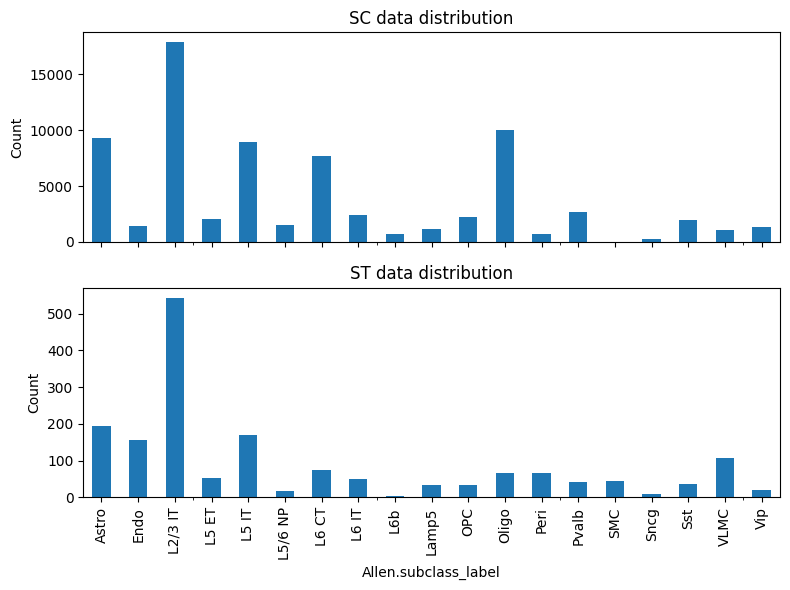

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# SC data
adata_sc.obs['Allen.subclass_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], rot=90
)
axes[0].set_title("SC data distribution")
axes[0].set_ylabel("Count")

# ST data
adata_st.obs['Allen.subclass_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], rot=90
)
axes[1].set_title("ST data distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

We can see that relative frequencies are actually quite homogeneus, suggesting that stratification might not be very beneficial.

With these harmonized datasets we can already run Tangram in filter mode and compare the filter results with the full labels dataset:

# Sampling with CytoSPACE
In the Tangram Refinements paper they propose to select cells with the package *CytoSPACE*. 

CytoSPACE is natively a package that performs scRNA to ST data alignment, mainly for spot level technologies, by first matching the two modailities' observation counts with resampling and then solving a convex optimization problem.
In this context, the resampling utilities are integrated in Tangram to perform cell selection prior to training. 

The resampling step aligns the number of scRNA-seq cells per cell type to the target numbers estimated from the spatial transcriptomics (ST) data. For each cell type *k*, if the scRNA dataset contains more cells than required (`num_sc,k > num_ST,k`), a random subset of size `num_ST,k` is selected (downsampling, without replacement). Conversely, if fewer cells are available (`num_sc,k < num_ST,k`), cells are sampled with replacement until the target is reached (upsampling, by duplication). This ensures that the composition of the scRNA dataset matches the predicted cell type proportions in the ST data.

Alternatively, a synthetic data generation resampling technique can be adopted.

The main use case for this package, as mentioned above, is for spot level ST data. In case of single-cell resolution data, a specific mode is available. Documentation also suggests to use pre-annotated spatial data (natively, cell type is estimated from the sport expression profile) and to patch it down to smaller subsets.

In our case, ST data is already annotated and patched to managable slices and, considering that we only need to resample (no optimization), the code is re-implemented here. 

In [ ]:
# import cytpospace  # re-implement

In [37]:
def resample_cells(
    adata_sc,
    adata_st,
    sc_label: str,
    st_label: str,
    method: str = "duplicates",
    seed: int = 42
):
    """
    Resample scRNA-seq cells to match the cell type composition of a spatial dataset.
    
    Parameters
    ----------
    adata_sc : AnnData
        Single-cell RNA-seq AnnData object.
    adata_st : AnnData
        Spatial transcriptomics AnnData object.
    sc_label : str
        Column name in adata_sc.obs with cell type labels.
    st_label : str
        Column name in adata_st.obs with cell type labels.
    method : str
        Resampling method if upsampling is needed. Default "duplicates".
    seed : int
        Random seed.
        
    Returns
    -------
    AnnData
        Resampled scRNA-seq AnnData object.
    """
    rng = np.random.default_rng(seed)
    
    # Compute target counts from ST cell types
    target_counts = adata_st.obs[st_label].value_counts().to_dict()
    
    resampled_indices = []
    
    for ct, target_n in target_counts.items():
        sc_idx = adata_sc.obs.index[adata_sc.obs[sc_label] == ct]
        n_sc = len(sc_idx)

        if n_sc == 0:
            import warnings
            warnings.warn(f"Cell type '{ct}' exists in ST but not in scRNA. Skipping this cell type.")
            continue
        
        if n_sc >= target_n:
            # Downsample without replacement
            chosen = rng.choice(sc_idx, size=target_n, replace=False)
        else:
            # Upsample with replacement
            if method == "duplicates":
                chosen = rng.choice(sc_idx, size=target_n, replace=True)
            else:
                raise NotImplementedError("Synthetic generation not implemented")
        
        resampled_indices.extend(chosen)
    
    return adata_sc[resampled_indices].copy()


In [42]:
# Use
adata_sc_resampled = resample_cells(adata_sc, adata_st,
    sc_label='Allen.subclass_label',
    st_label='Allen.subclass_label')
adata_sc_resampled

C:\Users\enric\tangram\.venv\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


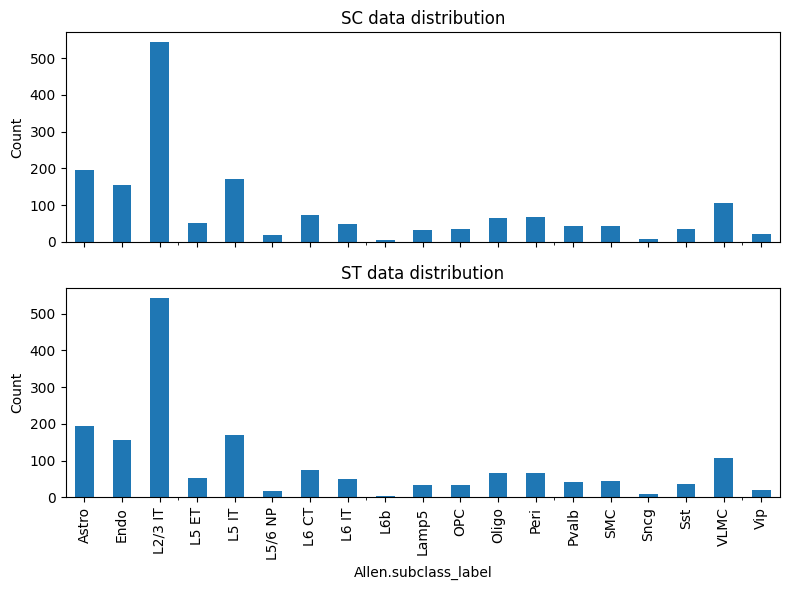

In [44]:
# Check result
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# SC data
adata_sc_resampled.obs['Allen.subclass_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], rot=90
)
axes[0].set_title("SC data distribution")
axes[0].set_ylabel("Count")

# ST data
adata_st.obs['Allen.subclass_label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], rot=90
)
axes[1].set_title("ST data distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()